In [28]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [29]:
df = yf.download("GOOG",'2025-01-01') #import data from yfinance (GOOG)

/tmp/ipython-input-566474997.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG",'2025-01-01') #import data from yfinance (GOOG)
[*********************100%***********************]  1 of 1 completed


In [30]:
returns = np.log(1+df["Close"].pct_change()) #normalize th non stationary data

In [31]:
T = 1.0 #define year and trading day
N = 252
dt = T / N
sigma = np.std(returns, ddof=1) / np.sqrt(dt)
mean = np.mean(returns) / dt + 0.5 * sigma**2

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [32]:
Z0 = df["Close"].iloc[-1] #last trading day
M = 1000 #No. of simulation
S = np.zeros((N + 1, M))
S[0] = Z0.item()
for t in range(1, N + 1):
    Z = np.random.normal(0, 1, M)
    S[t] = S[t - 1] * np.exp((mean.item() - 0.5 * sigma.item()**2) * dt + sigma.item() * np.sqrt(dt) * Z)

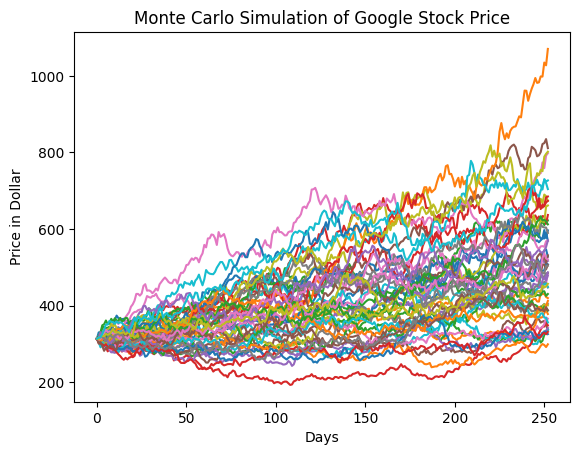

In [41]:
import matplotlib.pyplot as plt

plt.plot(S[:, :50])  # plot 50 sample paths
plt.title("Monte Carlo Simulation of Google Stock Price")
plt.xlabel("Days")
plt.ylabel("Price in Dollar")
plt.show()

In [34]:
np.mean(S[-1]) #at the end of year 2026 we expected the price of google stock is 546 dollar

np.float64(544.5621629187295)